# UCR Archive EDA Notebook
General notebook to explore UCR datasets (not tied to one dataset).

In [10]:
from pathlib import Path
import pandas as pd
import matplotlib.pyplot as plt

# Resolve the UCR archive root across common folder layouts
_root_candidates = [
    (Path('..') / '..' / 'data' / 'UCRArchive_2018').resolve(),
    (Path('..') / '..' / 'data' / 'UCRArchive_2018' / 'UCRArchive_2018').resolve(),
]
UCR_ROOT = next((p for p in _root_candidates if p.exists()), _root_candidates[0])
UCR_ROOT


WindowsPath('D:/repositories/personal/xai-spatio-temporal/data/UCRArchive_2018')

In [8]:
# Build a summary table for all datasets with TRAIN/TEST pairs
rows = []
for train_path in sorted(UCR_ROOT.rglob('*_TRAIN.tsv')):
    test_path = train_path.with_name(train_path.name.replace('_TRAIN.tsv', '_TEST.tsv'))
    if not test_path.exists():
        continue

    dataset = train_path.stem.replace('_TRAIN', '')
    train_df = pd.read_csv(train_path, sep='\t', header=None)
    test_df = pd.read_csv(test_path, sep='\t', header=None)

    rows.append({
        'dataset': dataset,
        'train_rows': len(train_df),
        'test_rows': len(test_df),
        'total_rows': len(train_df) + len(test_df),
        'columns': train_df.shape[1],
        'features': train_df.shape[1] - 1
    })

if not rows:
    raise ValueError(
        f'No *_TRAIN.tsv/*_TEST.tsv dataset pairs found under: {UCR_ROOT}. '
        'Check UCR_ROOT and folder structure.'
    )

summary_df = pd.DataFrame(rows).sort_values('total_rows', ascending=False).reset_index(drop=True)
summary_df.head(15)


,dataset,train_rows,test_rows,total_rows,columns,features
0,Crop,7200,16800,24000,47,46
1,ElectricDevices,8926,7711,16637,97,96
2,StarLightCurves,1000,8236,9236,1025,1024
3,Wafer,1000,6164,7164,153,152
4,ECG5000,500,4500,5000,141,140
5,TwoPatterns,1000,4000,5000,129,128
6,FordA,3601,1320,4921,501,500
7,UWaveGestureLibraryX,896,3582,4478,316,315
8,UWaveGestureLibraryY,896,3582,4478,316,315
9,UWaveGestureLibraryAll,896,3582,4478,946,945


In [6]:
# Choose any dataset here
dataset_name = 'ECG200'
train_path = UCR_ROOT / dataset_name / f'{dataset_name}_TRAIN.tsv'
test_path = UCR_ROOT / dataset_name / f'{dataset_name}_TEST.tsv'

train_df = pd.read_csv(train_path, sep='\t', header=None)
test_df = pd.read_csv(test_path, sep='\t', header=None)

print('Dataset:', dataset_name)
print('Train shape:', train_df.shape)
print('Test shape:', test_df.shape)
print('Feature count:', train_df.shape[1] - 1)

display(train_df.head())
print('Class distribution (train):')
print(train_df[0].value_counts().sort_index())

Dataset: ECG200
Train shape: (100, 97)
Test shape: (100, 97)
Feature count: 96


,0,1,2,3,4,5,6,7,8,9,...,87,88,89,90,91,92,93,94,95,96
0,-1,0.502055,0.542163,0.722383,1.428885,2.136516,2.281149,1.936274,1.468890,1.008845,...,0.931043,0.610298,0.638894,0.684679,0.583238,0.640522,0.708585,0.705011,0.713815,0.433765
1,1,0.147647,0.804668,0.367771,0.243894,0.026614,-0.274402,0.096731,-0.747731,-1.609777,...,-0.533503,-0.400228,0.176084,1.111768,2.438428,2.734889,1.736054,0.036857,-1.265074,-0.208024
2,-1,0.316646,0.243199,0.370471,1.063738,1.678187,1.759558,1.697717,1.612159,1.168188,...,0.764229,0.610621,0.552900,0.566786,0.604002,0.777068,0.812345,0.748848,0.818042,0.539347
3,-1,1.168874,2.075901,1.760141,1.606446,1.949046,1.302842,0.459332,0.516412,0.852180,...,0.419006,0.723888,1.323947,2.136488,1.746597,1.470220,1.893512,1.256949,0.800407,0.731540
4,1,0.648658,0.752026,2.636231,3.455716,2.118157,0.520620,-0.188627,0.780818,0.933775,...,-0.097869,-0.136787,-0.340237,-0.089441,-0.080297,-0.192584,-0.304704,-0.454556,0.314590,0.582190


Class distribution (train):
0
-1    31
 1    69
Name: count, dtype: int64


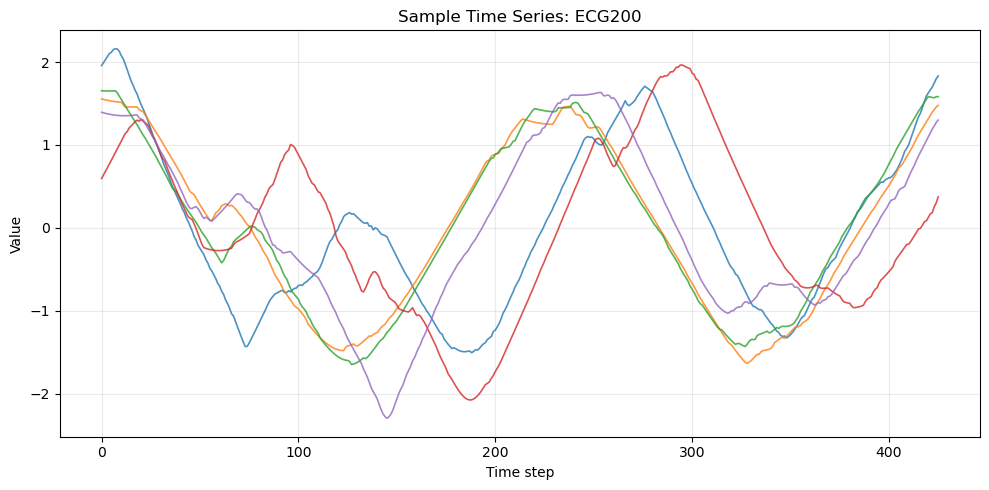

In [9]:
# Plot a few sample time series from selected dataset
num_samples = 5
sample_df = train_df.sample(min(num_samples, len(train_df)), random_state=42)

plt.figure(figsize=(10, 5))
for _, row in sample_df.iterrows():
    label = int(row.iloc[0])
    series = row.iloc[1:].to_numpy()
    plt.plot(series, alpha=0.8, linewidth=1.2, label=f'class {label}')

plt.title(f'Sample Time Series: {dataset_name}')
plt.xlabel('Time step')
plt.ylabel('Value')
plt.grid(alpha=0.25)
plt.tight_layout()
plt.show()